<a href="https://colab.research.google.com/github/mwjallen/JamesBondGadgets/blob/master/flt_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load the Airline Flight Data

In [ ]:
df = pd.read_csv('/content/sample_data/airlines_flights_data.csv')
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Cleaning the data

In [ ]:
#Drop the additional index column as it is not required
df.drop(['index'], axis=1, inplace=True)

In [ ]:
df.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [ ]:
# Longest duration
df[df['duration']==49.830000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
193889,Air_India,AI-672,Chennai,Evening,two_or_more,Evening,Bangalore,Economy,49.83,2,23891
194359,Air_India,AI-672,Chennai,Evening,one,Evening,Bangalore,Economy,49.83,9,17538


In [ ]:

# Shortest Duration
df[df['duration']==0.830000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
115869,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,6,3498
115943,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,7,3498
116010,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,8,3498
116081,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,9,3498
116163,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,10,3498
116236,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,11,3498
116322,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,12,3498
116411,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,13,3498
116496,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,14,3498
116656,Indigo,6E-357,Bangalore,Night,zero,Night,Chennai,Economy,0.83,16,1924


In [ ]:
# Maximum price
df[df['price']==123071.000000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
261377,Vistara,UK-772,Kolkata,Morning,one,Night,Delhi,Business,13.5,3,123071


In [ ]:
# Minimum price
df[df['price']==1105.000000]

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
203807,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,16,1105
203808,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,16,1105
203908,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,17,1105
203909,GO_FIRST,G8-505,Chennai,Evening,zero,Evening,Hyderabad,Economy,1.25,17,1105
204003,AirAsia,I5-517,Chennai,Morning,zero,Morning,Hyderabad,Economy,1.17,18,1105
...,...,...,...,...,...,...,...,...,...,...,...
206601,Indigo,6E-7261,Chennai,Morning,one,Evening,Hyderabad,Economy,7.92,49,1105
206602,Indigo,6E-611,Chennai,Evening,one,Late_Night,Hyderabad,Economy,8.25,49,1105
206603,Indigo,6E-581,Chennai,Morning,one,Evening,Hyderabad,Economy,9.17,49,1105
206604,Indigo,6E-7127,Chennai,Afternoon,one,Night,Hyderabad,Economy,9.50,49,1105


In [ ]:
# checking for nulls
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


### 1. What are the airlines in the dataset, accompanied by their frequencies?

In [ ]:
df['airline'].nunique()

6

In [ ]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [ ]:
#showing all airlines with their frequencies
air_count=df['airline'].value_counts(ascending=True)
air_count

,count
airline,
SpiceJet,9011
AirAsia,16098
GO_FIRST,23173
Indigo,43120
Air_India,80892
Vistara,127859


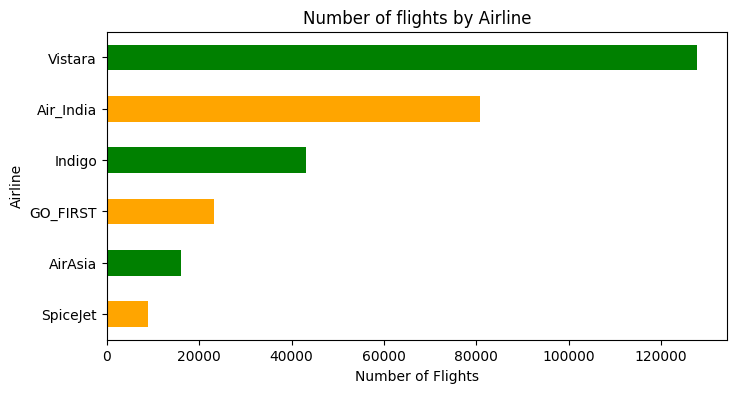

In [ ]:
# showing all airlines and number of flights in a horizontal bar graph
plt.figure(figsize=(8,4))
air_count.plot(
    kind='barh',
    x=air_count.index,
    y=air_count.values,
    color=['orange','green']
)

plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.title('Number of flights by Airline')
plt.show()

## 2. Show bar graphs representing the Departure Time & Arrival Time

In [ ]:
df.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [ ]:
#showing the departure time for flights
df['departure_time'].value_counts()

,count
departure_time,
Morning,71146
Early_Morning,66790
Evening,65102
Night,48015
Afternoon,47794
Late_Night,1306


In [ ]:
#showing the arrival time for flights
df['arrival_time'].value_counts()

,count
arrival_time,
Night,91538
Evening,78323
Morning,62735
Afternoon,38139
Early_Morning,15417
Late_Night,14001


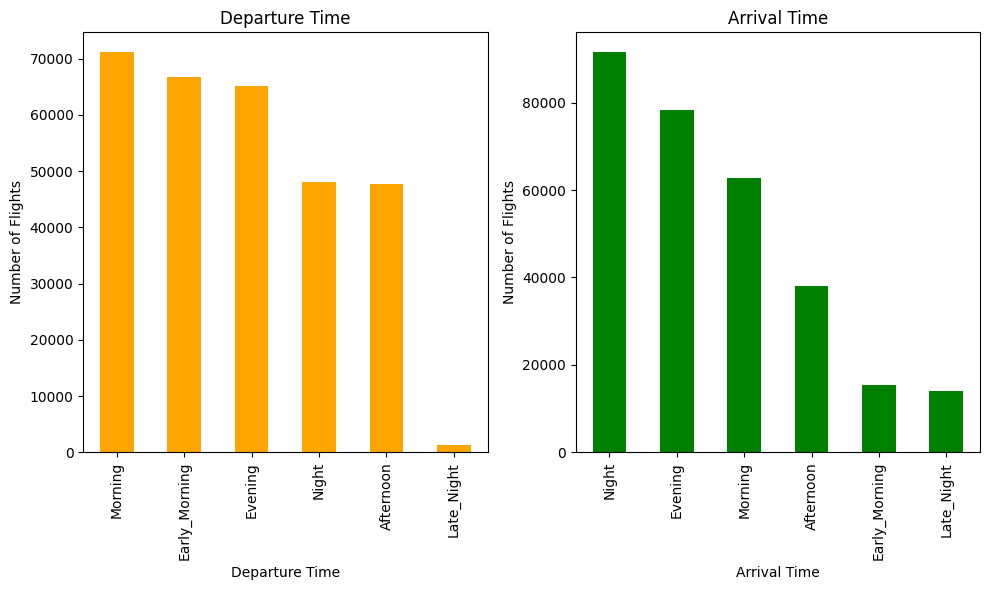

In [ ]:
#showing the departure & arrival times for tghe flights with counts using subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

plt.subplot(1,2,1)
df['departure_time'].value_counts().plot(kind='bar', color='orange')
plt.xlabel('Departure Time')
plt.ylabel('Number of Flights')
plt.title('Departure Time')

plt.subplot(1,2,2)
df['arrival_time'].value_counts().plot( kind='bar', color='green')
plt.xlabel('Arrival Time')
plt.ylabel('Number of Flights')
plt.title('Arrival Time')

plt.tight_layout()
plt.show()





### Show bar graphs representing the source city and destination city

In [ ]:
df.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [ ]:
df['source_city'].value_counts()


,count
source_city,
Delhi,61343
Mumbai,60896
Bangalore,52061
Kolkata,46347
Hyderabad,40806
Chennai,38700


In [ ]:
df['destination_city'].value_counts()

,count
destination_city,
Mumbai,59097
Delhi,57360
Bangalore,51068
Kolkata,49534
Hyderabad,42726
Chennai,40368


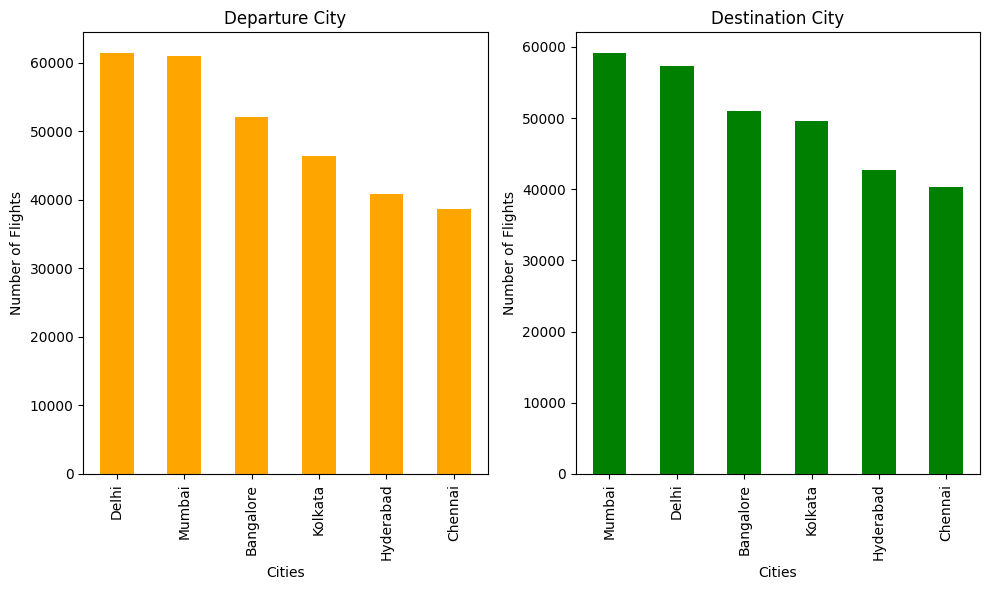

In [ ]:
#showing the departure & arrival cities for the flights with counts using subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

plt.subplot(1,2,1)
df['source_city'].value_counts().plot(kind='bar', color='orange')
plt.xlabel('Cities')
plt.ylabel('Number of Flights')
plt.title('Departure City')

plt.subplot(1,2,2)
df['destination_city'].value_counts().plot( kind='bar', color='green')
plt.xlabel('Cities')
plt.ylabel('Number of Flights')
plt.title('Destination City')

plt.tight_layout()
plt.show()

### Does the price vary by airline?

In [ ]:
df.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [ ]:
flt_mean_price=df.groupby('airline')['price'].mean()
flt_mean_price

,price
airline,
AirAsia,4091.072742
Air_India,23507.019112
GO_FIRST,5652.007595
Indigo,5324.216303
SpiceJet,6179.278881
Vistara,30396.536302


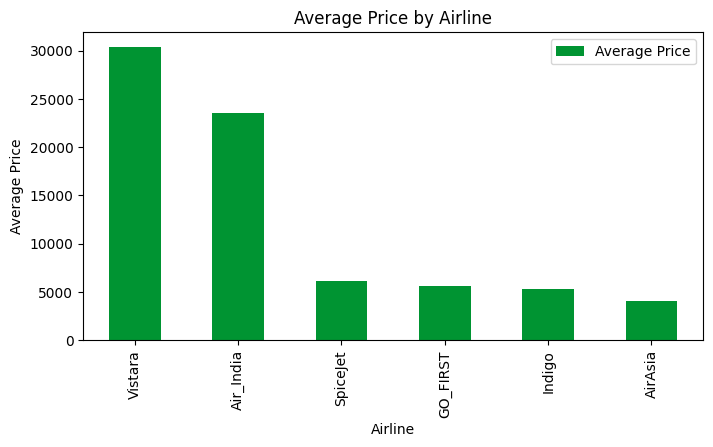

In [ ]:
plt.figure(figsize=(8,4))
df.groupby('airline')['price'].mean().sort_values(ascending=False).plot(kind='bar', color='#009432')
plt.xlabel('Airline')
plt.ylabel('Average Price')
plt.title('Average Price by Airline')
plt.legend(['Average Price'])
plt.show()

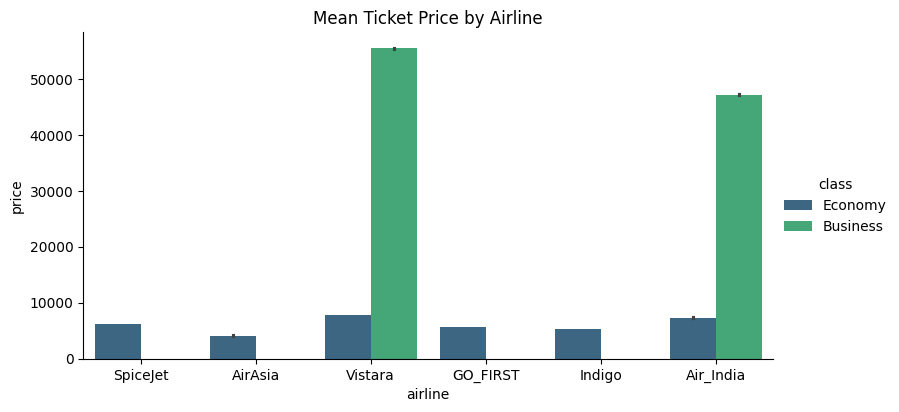

In [ ]:
# drawing a categorical plot showing the mean ticket price for each airline
sns.catplot(
    data=df,
    x='airline',
    y='price',
    kind='bar',
    palette='viridis',
    hue='class',
    height=4,
    aspect=2
)
plt.title('Mean Ticket Price by Airline')
plt.show()

### Does ticket price change based on departure time and arrival time??

In [ ]:
# Does ticket price change based on departure time and arrival time
df.groupby('departure_time')['price'].mean().sort_values(ascending=False)

,price
departure_time,
Night,23062.146808
Morning,21630.760254
Evening,21232.361894
Early_Morning,20370.676718
Afternoon,18179.203331
Late_Night,9295.299387


In [ ]:
df.groupby('arrival_time')['price'].mean().sort_values(ascending=False)

,price
arrival_time,
Evening,23044.371615
Morning,22231.076098
Night,21586.758341
Afternoon,18494.598993
Early_Morning,14993.139521
Late_Night,11284.906078


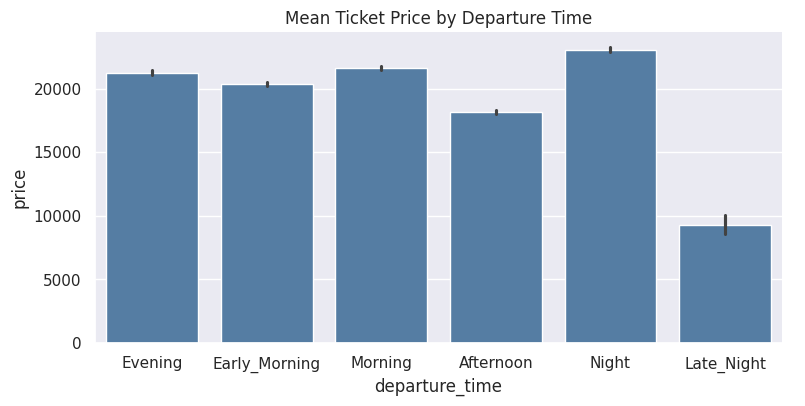

In [ ]:

sns.catplot(
    kind='bar',
    data=df,
    x='departure_time',
    y='price',
    height=4,
    aspect=2,
    color='#487eb0'
)
plt.title('Mean Ticket Price by Departure Time')
plt.show()

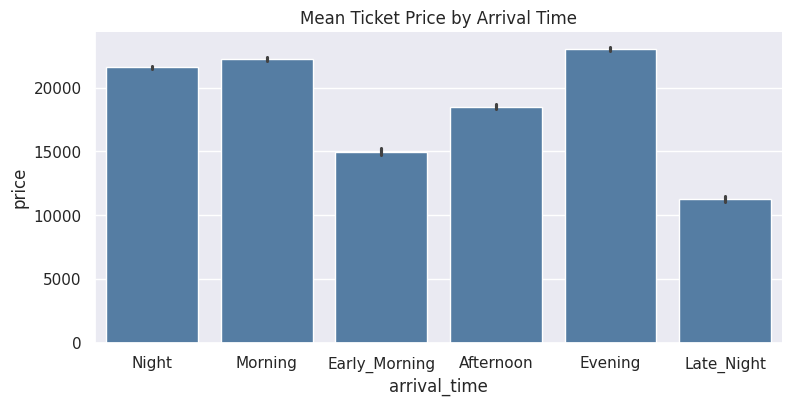

In [ ]:
sns.catplot(
    kind='bar',
    data=df,
    x='arrival_time',
    y='price',
    height=4,
    aspect=2,
    color='#487eb0'
)
plt.title('Mean Ticket Price by Arrival Time')
plt.show()

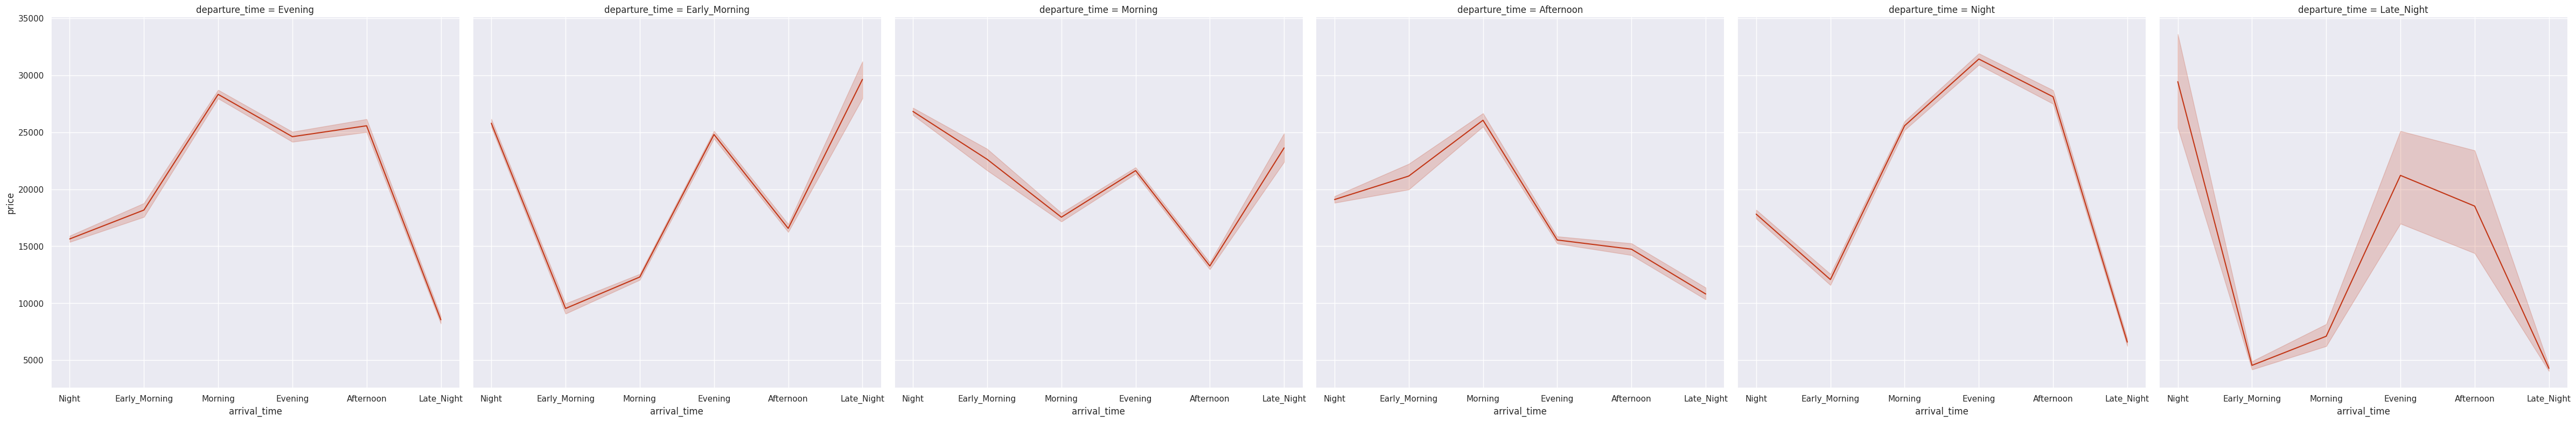

In [ ]:
# draw a relational plot
sns.relplot(
    data=df,
    kind='line',
    x='arrival_time',
    y='price',
    col='departure_time',
    height=8,
    aspect=1,
    color='#c23616'
)

plt.show()